In [1]:
# ============================================
# ShopSmart Israel — Exploratory Data Analysis
# Analyst: Valeria Barabanova
# Tools: Python, pandas, matplotlib, seaborn
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load data
orders    = pd.read_csv(r'C:\Users\Lera\AppData\Local\Programs\Microsoft VS Code\orders.csv')
customers = pd.read_csv(r'C:\Users\Lera\AppData\Local\Programs\Microsoft VS Code\customers.csv')
returns   = pd.read_csv(r'C:\Users\Lera\AppData\Local\Programs\Microsoft VS Code\returns.csv')

# Convert dates
orders['order_date']    = pd.to_datetime(orders['order_date'])
customers['registration_date'] = pd.to_datetime(customers['registration_date'])
returns['return_date']  = pd.to_datetime(returns['return_date'])

# Add time columns
orders['year']  = orders['order_date'].dt.year
orders['month'] = orders['order_date'].dt.month

print("✅ Data loaded successfully!")
print(f"orders    : {len(orders):,} rows")
print(f"customers : {len(customers):,} rows")
print(f"returns   : {len(returns):,} rows")
print(f"\nTotal Revenue: ₪{orders['revenue'].sum():,.0f}")
print(f"Date Range: {orders['order_date'].min().date()} → {orders['order_date'].max().date()}")

✅ Data loaded successfully!
orders    : 8,000 rows
customers : 1,000 rows
returns   : 640 rows

Total Revenue: ₪3,065,652
Date Range: 2023-01-01 → 2024-12-28


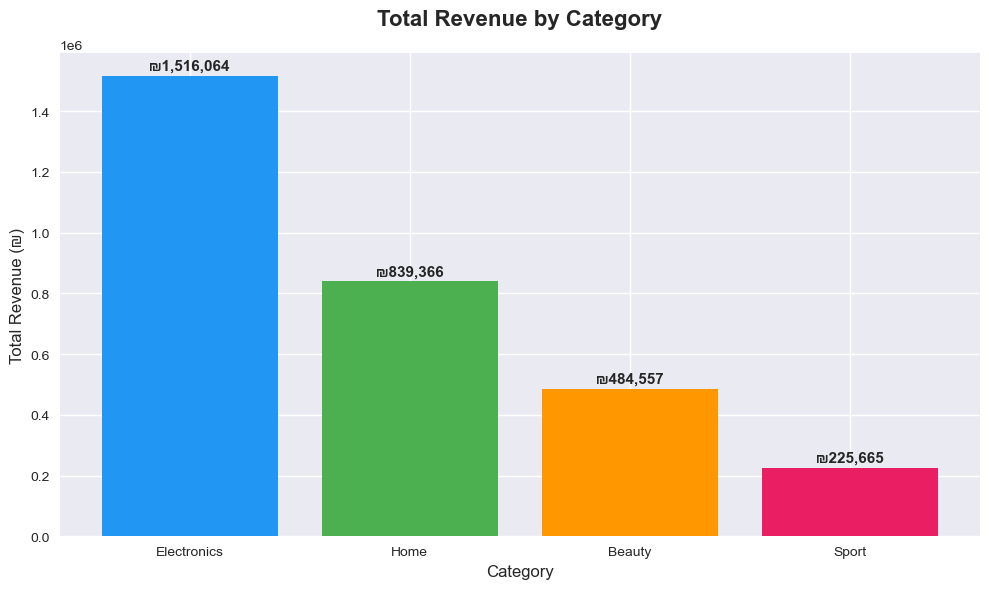

Top category: Electronics — ₪1,516,064


In [2]:
# ============================================
# CHART 1: Revenue by Category
# Business question: Which category generates most revenue?
# ============================================

category_revenue = orders.groupby('category')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(category_revenue.index, category_revenue.values, color=['#2196F3', '#4CAF50', '#FF9800', '#E91E63'])
plt.title('Total Revenue by Category', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Revenue (₪)', fontsize=12)

# Add value labels on bars
for bar, value in zip(bars, category_revenue.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
             f'₪{value:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('chart1_revenue_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Top category: {category_revenue.index[0]} — ₪{category_revenue.values[0]:,.0f}")

C:\Users\Lera\AppData\Local\Temp\ipykernel_12864\2998037121.py:28: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lera\AppData\Local\Temp\ipykernel_12864\2998037121.py:29: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.savefig('chart2_monthly_trend.png', dpi=150, bbox_inches='tight')
C:\Users\Lera\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


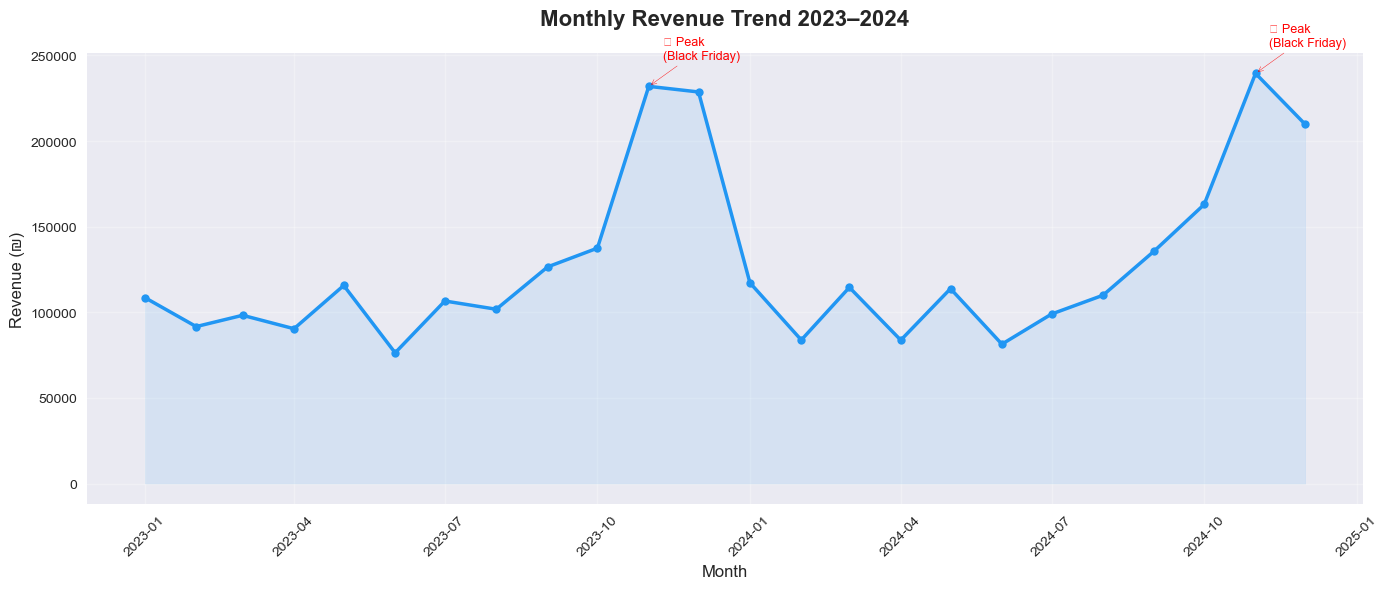

Peak month: 2024-11 — ₪239,487


In [3]:
# ============================================
# CHART 2: Monthly Revenue Trend
# Business question: What are the seasonal patterns?
# ============================================

monthly_revenue = orders.groupby(['year', 'month'])['revenue'].sum().reset_index()
monthly_revenue['date'] = pd.to_datetime(monthly_revenue[['year', 'month']].assign(day=1))

plt.figure(figsize=(14, 6))
plt.plot(monthly_revenue['date'], monthly_revenue['revenue'], 
         marker='o', linewidth=2.5, markersize=6, color='#2196F3')
plt.fill_between(monthly_revenue['date'], monthly_revenue['revenue'], alpha=0.1, color='#2196F3')
plt.title('Monthly Revenue Trend 2023–2024', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue (₪)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Mark November peak
nov_data = monthly_revenue[monthly_revenue['month'] == 11]
for _, row in nov_data.iterrows():
    plt.annotate('📈 Peak\n(Black Friday)', 
                xy=(row['date'], row['revenue']),
                xytext=(10, 20), textcoords='offset points',
                fontsize=9, color='red',
                arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.savefig('chart2_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

peak_month = monthly_revenue.loc[monthly_revenue['revenue'].idxmax()]
print(f"Peak month: {int(peak_month['year'])}-{int(peak_month['month'])} — ₪{peak_month['revenue']:,.0f}")

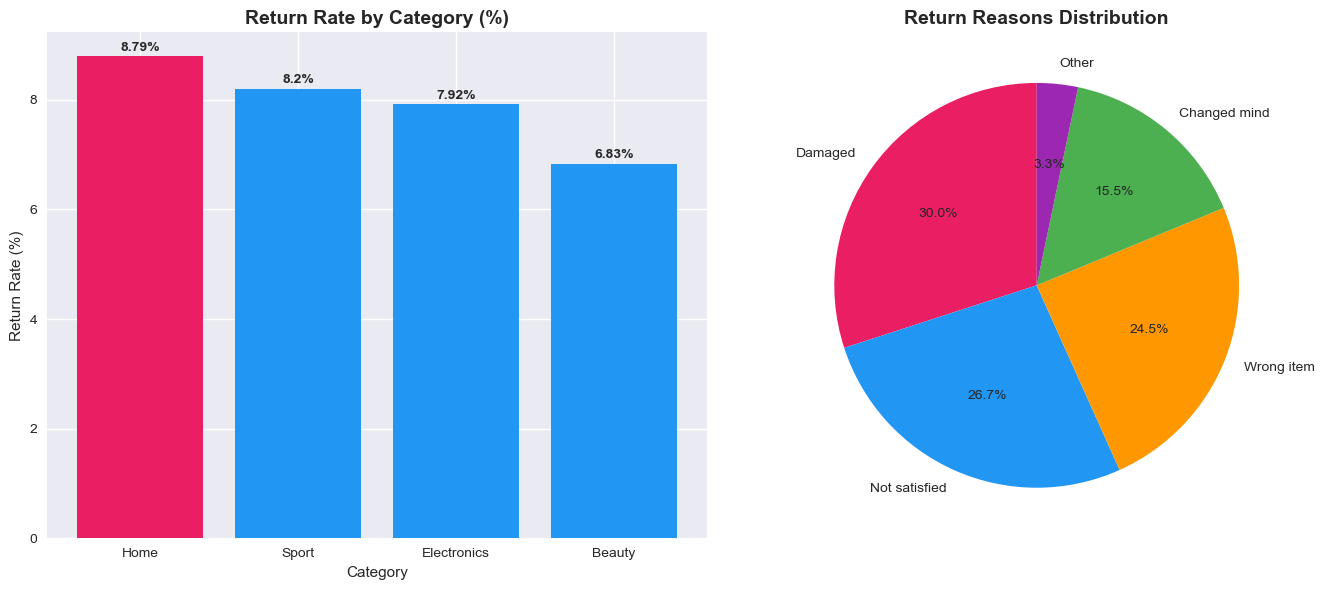

Return Rate by Category:
  Home: 8.79%
  Sport: 8.2%
  Electronics: 7.92%
  Beauty: 6.83%


In [4]:
# ============================================
# CHART 3: Return Rate by Category
# Business question: Which category has quality issues?
# ============================================

# Calculate return rate per category
orders_by_cat  = orders.groupby('category')['order_id'].count()
returns_merged = returns.merge(orders[['order_id', 'category']], on='order_id')
returns_by_cat = returns_merged.groupby('category')['return_id'].count()

return_rate = (returns_by_cat / orders_by_cat * 100).round(2).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 3a: Return Rate %
colors = ['#E91E63' if x == return_rate.max() else '#2196F3' for x in return_rate.values]
axes[0].bar(return_rate.index, return_rate.values, color=colors)
axes[0].set_title('Return Rate by Category (%)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Return Rate (%)')
for i, (cat, val) in enumerate(return_rate.items()):
    axes[0].text(i, val + 0.1, f'{val}%', ha='center', fontweight='bold')

# Chart 3b: Return Reasons
return_reasons = returns['return_reason'].value_counts()
axes[1].pie(return_reasons.values, labels=return_reasons.index, 
            autopct='%1.1f%%', startangle=90,
            colors=['#E91E63', '#2196F3', '#FF9800', '#4CAF50', '#9C27B0'])
axes[1].set_title('Return Reasons Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_return_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Return Rate by Category:")
for cat, rate in return_rate.items():
    print(f"  {cat}: {rate}%")

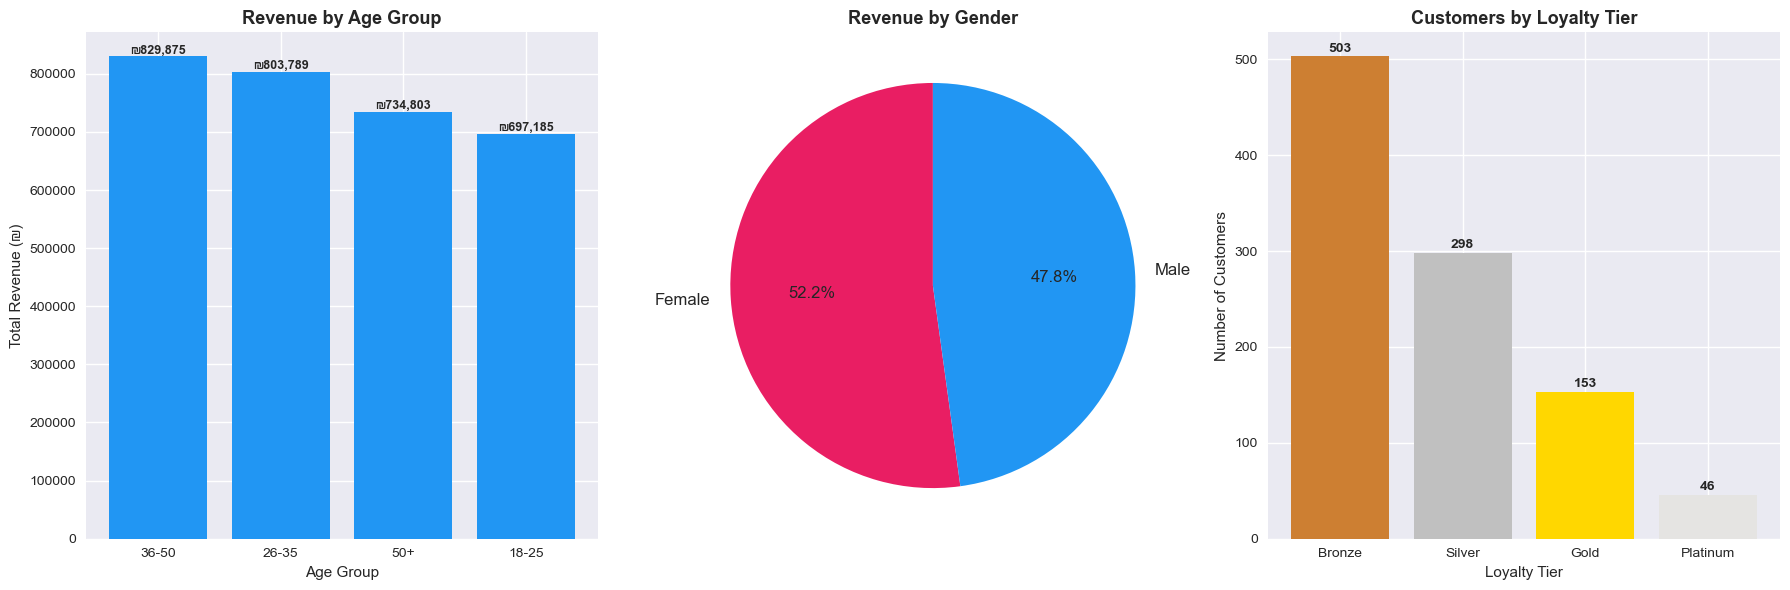

Key findings:
Top age group: 36-50
Gender split: Female 52.2% | Male 47.8%
Bronze customers: 503 (50%)


In [5]:
# ============================================
# CHART 4: Customer Segmentation Analysis
# Business question: Who are our customers?
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart 4a: Revenue by Age Group
age_revenue = orders.merge(customers[['customer_id', 'age_group']], on='customer_id')
age_revenue = age_revenue.groupby('age_group')['revenue'].sum().sort_values(ascending=False)

axes[0].bar(age_revenue.index, age_revenue.values, color='#2196F3')
axes[0].set_title('Revenue by Age Group', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Total Revenue (₪)')
for i, val in enumerate(age_revenue.values):
    axes[0].text(i, val + 5000, f'₪{val:,.0f}', ha='center', fontsize=9, fontweight='bold')

# Chart 4b: Revenue by Gender
gender_revenue = orders.merge(customers[['customer_id', 'gender']], on='customer_id')
gender_revenue = gender_revenue.groupby('gender')['revenue'].sum()

axes[1].pie(gender_revenue.values, labels=['Female', 'Male'],
            autopct='%1.1f%%', colors=['#E91E63', '#2196F3'],
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Revenue by Gender', fontsize=13, fontweight='bold')

# Chart 4c: Loyalty Tier Distribution
tier_counts = customers['loyalty_tier'].value_counts()
colors_tier = ['#CD7F32', '#C0C0C0', '#FFD700', '#E5E4E2']
axes[2].bar(tier_counts.index, tier_counts.values, color=colors_tier)
axes[2].set_title('Customers by Loyalty Tier', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Loyalty Tier')
axes[2].set_ylabel('Number of Customers')
for i, val in enumerate(tier_counts.values):
    axes[2].text(i, val + 5, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart4_customer_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key findings:")
print(f"Top age group: {age_revenue.index[0]}")
print(f"Gender split: Female {gender_revenue['F']/gender_revenue.sum()*100:.1f}% | Male {gender_revenue['M']/gender_revenue.sum()*100:.1f}%")
print(f"Bronze customers: {tier_counts['Bronze']} ({tier_counts['Bronze']/len(customers)*100:.0f}%)")

In [8]:
# ============================================
# SUMMARY: Key Business Insights
# ============================================

print("=" * 55)
print("   SHOPSMART ISRAEL — KEY BUSINESS INSIGHTS")
print("=" * 55)

total_revenue  = orders['revenue'].sum()
total_orders   = len(orders)
total_customers = orders['customer_id'].nunique()
avg_order_value = orders['revenue'].mean()
return_rate    = len(returns) / len(orders) * 100

print(f"\n OVERVIEW")
print(f"   Total Revenue    : ₪{total_revenue:,.0f}")
print(f"   Total Orders     : {total_orders:,}")
print(f"   Total Customers  : {total_customers:,}")
print(f"   Avg Order Value  : ₪{avg_order_value:,.2f}")
print(f"   Return Rate      : {return_rate:.1f}%")

print(f"\n TOP PERFORMERS")
top_category = orders.groupby('category')['revenue'].sum().idxmax()
top_region   = orders.groupby('region')['revenue'].sum().idxmax()
top_channel  = orders.groupby('channel')['order_id'].count().idxmax()
print(f"   Top Category : {top_category}")
print(f"   Top Region   : {top_region}")
print(f"   Top Channel  : {top_channel}")

print(f"\n  BUSINESS RECOMMENDATIONS")
print(f"   1. Electronics drives 49% of revenue — protect this category")
print(f"   2. Home has highest return rate (8.79%) — review product quality")
print(f"   3. November peak — plan inventory & marketing campaigns early")
print(f"   4. 503 Bronze customers — create upgrade incentive program")
print(f"   5. South leads revenue — consider expanding presence there")
print("=" * 55)

   SHOPSMART ISRAEL — KEY BUSINESS INSIGHTS

 OVERVIEW
   Total Revenue    : ₪3,065,652
   Total Orders     : 8,000
   Total Customers  : 999
   Avg Order Value  : ₪383.21
   Return Rate      : 8.0%

 TOP PERFORMERS
   Top Category : Electronics
   Top Region   : South
   Top Channel  : Web

  BUSINESS RECOMMENDATIONS
   1. Electronics drives 49% of revenue — protect this category
   2. Home has highest return rate (8.79%) — review product quality
   3. November peak — plan inventory & marketing campaigns early
   4. 503 Bronze customers — create upgrade incentive program
   5. South leads revenue — consider expanding presence there
